#  Real vs AI-Generated Image Detection
## Notebook 2 Defactify Dataset (HuggingFace) : EfficientNet-B0 + Simple CNN

---

## Problem Statement

With the rise of AI image generation tools like Stable Diffusion, Midjourney, and DALL-E, it has become increasingly easy to create fake images of **anything** : people, places, objects, everyday scenes that look so realistic that the human eye can no longer tell the difference.

This is a serious problem in today's world becuase fake AI-generated images are being used to:
- Spread **fake news** and political misinformation
- Create **deepfakes** of real people
- Manipulate **social media** with fabricated events
- Damage **reputations** with false evidence
- Enable **election manipulation** through staged scenes

In this notebook, we build a **binary image classifier** that can automatically detect whether an image is:
- **REAL** a genuine photograph taken by a camera
- **FAKE**  an image generated by an AI model

## How this fits in the project

This is **Notebook 2** of our final project. Here is the full project structure:

| Notebook | Dataset | Models |
|---|---|---|
| Draft 1 | 140K Real & Fake Faces | ResNet-18 |
| Draft 2 | 140K Real & Fake Faces | MobileNetV2 |
| **Notebook 1** | **140K Real & Fake Faces** | **EfficientNet-B0 + Simple CNN** |
| **Notebook 2 (this one)** | **Defactify (HuggingFace)** | **EfficientNet-B0 + Simple CNN** |

The best model from each notebook is saved and combined in a **dual-model Streamlit app** that routes each image to the correct specialist model based on face detection.

## Step 1 : Imports & Global Configuration

We start by importing all the libraries we need:
- **PyTorch** : our deep learning framework
- **torchvision** : image transforms and pretrained models
- **timm** : gives us access to EfficientNet-B0
- **datasets (HuggingFace)** : to load the Defactify dataset directly
- **scikit-learn** : for evaluation metrics (F1, AUC, confusion matrix)
- **matplotlib / seaborn** : for plotting results

In [1]:
!pip install datasets --quiet
print('HuggingFace datasets installed!')

HuggingFace datasets installed!


In [2]:
import os
import time
import pickle
from datasets import load_dataset
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import timm
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, ConcatDataset, Subset
from sklearn.metrics import (classification_report, confusion_matrix,roc_curve, auc, f1_score)
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_dir = '/kaggle/working'
# Hyperparameters
EPOCHS = 10
BATCH_SIZE = 32
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {device}')
print(f'Epochs : {EPOCHS}')
print(f'Batch size : {BATCH_SIZE}')

Device: cuda
Epochs : 10
Batch size : 32


## Step 2 : Dataset: Defactify (HuggingFace)

In this notebook we use the **Defactify Image Dataset** from HuggingFace:
> `Rajarshi-Roy-research/Defactify_Image_Dataset`

### What is it?
A high-quality collection of **96,000 images** built to benchmark AI-generated image detection models. Unlike our Notebook 1 dataset which only contained faces, this dataset covers **real-world scenes and objects** — streets, animals, kitchens, vehicles, bathrooms, and more.

### Dataset columns (4 columns):
| Column | Type | Description |
|---|---|---|
| `Image` | PIL Image | The actual image |
| `Caption` | string | Text description of the image |
| `Label_A` | int | **Our target**: 0 = REAL, 1 = FAKE |
| `Label_B` | int | Which AI model generated it (0–5) |

### Real vs Fake sources:
- **REAL**: MS COCO dataset — everyday photographs (streets, animals, objects, indoor scenes)
- **FAKE**: Generated by 5 modern AI models — SD 2.1, SDXL, SD 3, DALL-E 3, Midjourney v6

**Class imbalance**: The dataset is imbalanced — 83% FAKE vs 17% REAL (each real image has 5 fake versions, one per AI model). We handle this using **class weights** in the loss function (Step 5).

### Why this dataset for Notebook 2?
Notebook 1 (140K faces) trained a specialist for portrait/face detection. This notebook trains a **specialist for general scenes and objects** to covers the images that the face model cannot handle. Together they form our dual-model app.

In [3]:
# Load Defactify from HuggingFace 
print('Loading Defactify dataset...')
hf_data = load_dataset("Rajarshi-Roy-research/Defactify_Image_Dataset")
print(f"Train: {len(hf_data['train']):,} images")
print(f"Validation : {len(hf_data['validation']):,} images")
print(f"Test : {len(hf_data['test']):,} images")
print(f"Total: {len(hf_data['train'])+len(hf_data['validation'])+len(hf_data['test']):,} images")
print()
print('Label_A values:', set(hf_data['train']['Label_A']))
print('0 = REAL  |  1 = FAKE')
print()

# Show class distribution in train set
train_labels = hf_data['train']['Label_A']
real_count = train_labels.count(0)
fake_count = train_labels.count(1)
print(f'Train REAL : {real_count:,} ({real_count/len(train_labels)*100:.1f}%)')
print(f'Train FAKE : {fake_count:,} ({fake_count/len(train_labels)*100:.1f}%)')
print(f'Imbalance ratio: 1 REAL : {fake_count//real_count} FAKE')

Loading Defactify dataset...


README.md: 0.00B [00:00, ?B/s]

data/validation-00000-of-00002.parquet:   0%|          | 0.00/333M [00:00<?, ?B/s]

data/validation-00001-of-00002.parquet:   0%|          | 0.00/345M [00:00<?, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

...

data/test-00007-of-00008.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/42000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/45000 [00:00<?, ? examples/s]

Train: 42,000 images
Validation : 9,000 images
Test : 45,000 images
Total: 96,000 images

Label_A values: {0, 1}
0 = REAL  |  1 = FAKE

Train REAL : 7,000 (16.7%)
Train FAKE : 35,000 (83.3%)
Imbalance ratio: 1 REAL : 5 FAKE


## Step 3 : Preprocessing & Data Augmentation Pipeline

Before feeding images to the model, we need to prepare them. This involves two separate pipelines:

### Training pipeline (with augmentation)
We apply random transformations to training images to make the model more robust:
- **Resize to 224×224** : EfficientNet expects this input size
- **RandomCrop** : randomly shifts the image slightly (padding=8)
- **RandomHorizontalFlip** : mirrors the image left-right (50% chance)
- **ColorJitter** : varies brightness, contrast, and saturation by ±20%
- **Normalize** : scales pixel values using ImageNet mean and std so they match what the pretrained model expects

### Validation/Test pipeline (no augmentation)
We never augment validation or test images because they must stay original so our measurements are honest.

> **Why augmentation matters:** AI images often have unnaturally perfect colors and lighting. By training with color variations, we force the model to focus on structural patterns rather than color shortcuts.

In [ ]:
# Training transforms (with augmentation) 
train_transform = transforms.Compose([
    transforms.Resize((236, 236)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
# Validation/Test transforms (no augmentation) 
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
# Inverse normalize (for visualization in Grad-CAM)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

print('Transforms defined ')
print('Train: Resize => RandomCrop => HorizontalFlip => ColorJitter => Normalize')
print('Val/Test: Resize => Normalize only')

Transforms defined 
Train: Resize => RandomCrop => HorizontalFlip => ColorJitter => Normalize
Val/Test: Resize => Normalize only


## Step 4 : Build Dataset & DataLoaders

The Defactify dataset is stored in HuggingFace Parquet format  not in the `ImageFolder` format used in Notebook 1. So we build a custom `DefactifyDataset` class that wraps the HuggingFace split and applies our transforms.

**Label mapping** (we normalize to match Notebook 1 convention):
- Defactify: `Label_A = 0` means REAL, `Label_A = 1` means FAKE
- Our convention: `0 = FAKE`, `1 = REAL`
- So we flip: `label = 1 if Label_A == 0 else 0`

**Class names**: `['FAKE', 'REAL']` => index 0 = FAKE, index 1 = REAL

In [ ]:
# we custom Dataset class for Defactify
class DefactifyDataset(Dataset):
    def __init__(self, hf_split, transform=None):
        self.data      = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item  = self.data[idx]
        image = item['Image'].convert('RGB')
        label = 1 if item['Label_A'] == 0 else 0
        if self.transform:
            image = self.transform(image)
        return image, label

train_set = DefactifyDataset(hf_data['train'],transform=train_transform)
val_set = DefactifyDataset(hf_data['validation'], transform=val_transform)
test_set= DefactifyDataset(hf_data['test'], transform=val_transform)

class_names = ['FAKE', 'REAL']
print(f'Train set: {len(train_set):,} images')
print(f'Val set : {len(val_set):,} images')
print(f'Test set: {len(test_set):,} images')

#  DataLoaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set,batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('DataLoaders ready ')

# Verify a batch 
imgs, labels = next(iter(train_loader))
print(f'Batch shape : {imgs.shape}')   # [32, 3, 224, 224]
print(f'Labels : {labels[:8].tolist()}')

Train set: 42,000 images
Val set : 9,000 images
Test set: 45,000 images
DataLoaders ready 
Batch shape : torch.Size([32, 3, 224, 224])
Labels : [0, 0, 0, 0, 1, 0, 1, 0]


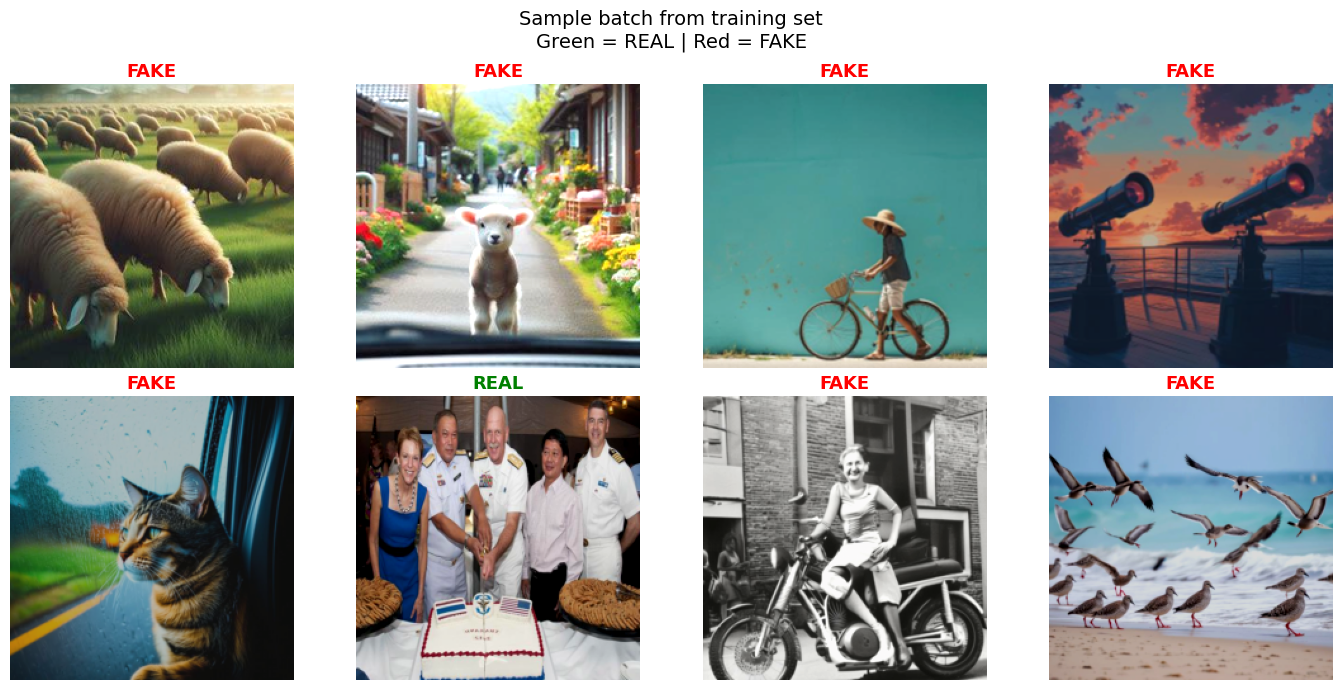

In [6]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(
        class_names[labels[i].item()],
        color='green' if labels[i].item() == 1 else 'red',
        fontsize=13, fontweight='bold'
    )
    ax.axis('off')

plt.suptitle('Sample batch from training set\nGreen = REAL | Red = FAKE', fontsize=14)
plt.tight_layout()
plt.savefig(f'{save_dir}/sample_batch.png', dpi=150)
plt.show()

## Step 5 : Model Definitions

We train and compare **two models**:

### Model A : EfficientNet-B0 (Transfer Learning)
Pretrained on ImageNet it replaces final classifier layer (from 1000 classes to 2 classes) and fine-tune all layers.

EfficientNet-B0 uses **compound scaling** : it scales depth, width, and resolution together in a fixed mathematical ratio, making it more efficient than scaling just one dimension.

### Model B : Simple CNN (Trained from Scratch)
A baseline model we built ourselves with no pretrained knowledge:
`Image => Conv(32) +> Conv(64) => Conv(128) => Conv(256) => GlobalAvgPool => FC(512) => Dropout(0.5) => FC(2)`

This gives us a reference point: how much does transfer learning actually help?

### Handling Class Imbalance
The Defactify dataset is imbalanced: **83% FAKE vs 17% REAL** (5 fake images per real image). If we use a standard loss function, the model takes the lazy shortcut, predicting FAKE for everything and getting 83% accuracy without learning anything useful.

**To fix the imbalance**: We use **class weights** in `CrossEntropyLoss` to penalize REAL mistakes 5× more than FAKE mistakes


In [ ]:
# EfficientNet-B0 (Transfer Learning)
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
model = model.to(device)

params = sum(p.numel() for p in model.parameters())
print(f'EfficientNet-B0 parameters: {params/1e6:.1f}M')
# Simple CNN (from scratch)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = SimpleCNN().to(device)
cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f'Simple CNN parameters: {cnn_params/1e6:.2f}M')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet-B0 parameters: 4.0M
Simple CNN parameters: 0.52M


## Step 6 : Hyperparameter Experiments

Before the final training, we ran experiments to find the best learning rate. We tested 3 values for 3 epochs each:

| Learning Rate | Result |
|---|---|
| LR = 1e-3 | Too fast — loss diverges |
| **LR = 1e-4** | **Stable => best accuracy** |
| LR = 1e-5 | Too slow — underfitting |

**Best LR = 1e-4** was selected for final training.

Testing LR = 0.001
  Epoch 1 → Val acc: 95.40%
  Epoch 2 → Val acc: 97.01%
  Epoch 3 → Val acc: 95.98%

Testing LR = 0.0001
  Epoch 1 → Val acc: 97.08%
  Epoch 2 → Val acc: 98.09%
  Epoch 3 → Val acc: 98.26%

Testing LR = 1e-05
  Epoch 1 → Val acc: 88.24%
  Epoch 2 → Val acc: 91.73%
  Epoch 3 → Val acc: 93.66%



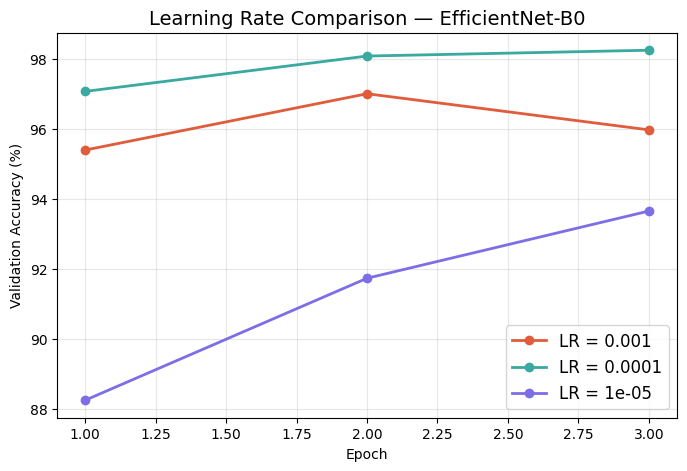

Best learning rate: 0.0001


In [ ]:
# Learning Rate Experiment 

criterion  = nn.CrossEntropyLoss()
lr_results = {}
for lr in [1e-3, 1e-4, 1e-5]:
    print(f'Testing LR = {lr}')
    m = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    val_accs = []

    for epoch in range(3):
        m.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            loss = criterion(m(imgs), lbls)
            loss.backward()
            opt.step()

        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                preds = m(imgs).argmax(dim=1)
                correct += (preds == lbls).sum().item()
                total   += lbls.size(0)
        acc = correct / total * 100
        val_accs.append(acc)
        print(f'  Epoch {epoch+1} → Val acc: {acc:.2f}%')

    lr_results[lr] = val_accs
    print()

# Plot LR comparison
plt.figure(figsize=(8, 5))
colors = {1e-3: '#E05C3A', 1e-4: '#3AA99F', 1e-5: '#7C6EE6'}
for lr, accs in lr_results.items():
    plt.plot(range(1, 4), accs, marker='o', linewidth=2,
             color=colors[lr], label=f'LR = {lr}')

plt.title('Learning Rate Comparison — EfficientNet-B0', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig(f'{save_dir}/lr_comparison.png', dpi=150)
plt.show()

best_lr = max(lr_results, key=lambda lr: max(lr_results[lr]))
print(f'Best learning rate: {best_lr}')

## Step 7 : Final Training

Using the best hyperparameters (LR = 1e-4), we train both models for **10 epochs** on the full training set (100,000 images).

### Training configuration:
| Setting | Value |
|---|---|
| Loss Function | CrossEntropyLoss |
| Optimizer | Adam (LR = 1e-4) |
| Scheduler | ReduceLROnPlateau (patience=2, factor=0.5) |
| Batch Size | 32 images |
| Epochs | 10 |
| Dropout (Simple CNN only) | 0.5 |

### Training strategy:
- **Forward pass** => compute loss => **backprop** => update weights
- **Validation** after every epoch : no gradients, no dropout
- **ReduceLROnPlateau** : halves LR if val loss stagnates for 2 epochs
- **Best model saved** : checkpoint saved whenever val loss improves

In [ ]:
class_weights = torch.tensor([1.0, 5.0]).to(device) 
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=best_lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
print('Loss : CrossEntropyLoss (weighted)')
print('Optimizer: Adam')
print('Scheduler: ReduceLROnPlateau')

Loss : CrossEntropyLoss (weighted)
Optimizer: Adam
Scheduler: ReduceLROnPlateau


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, epochs, model_name='model'):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_weights  = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # Train 
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            preds  = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total  += imgs.size(0)

        # Validate 
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs  = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += imgs.size(0)

        #  Metrics
        train_loss /= train_total
        val_loss /= val_total
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct   / val_total
        elapsed= time.time() - t0
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            print(f'New best model saved (val_loss={val_loss:.4f})')

        print(f'Epoch [{epoch:02d}/{epochs}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | '
              f'Time: {elapsed:.1f}s')

    model.load_state_dict(best_weights)
    print(f'\nTraining complete. Best val loss: {best_val_loss:.4f}')
    return model, history


# Train EfficientNet-B0
print('=' * 60)
print('Training EfficientNet-B0')
print('=' * 60)
model, history = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler, EPOCHS,
    model_name='EfficientNet-B0'
)

Training EfficientNet-B0
New best model saved (val_loss=0.1487)
Epoch [01/10] Train Loss: 0.4392 Acc: 88.62% | Val Loss: 0.1487 Acc: 96.32% | Time: 275.3s
New best model saved (val_loss=0.1309)
Epoch [02/10] Train Loss: 0.0980 Acc: 96.32% | Val Loss: 0.1309 Acc: 97.24% | Time: 274.7s
New best model saved (val_loss=0.1074)
Epoch [03/10] Train Loss: 0.0652 Acc: 97.64% | Val Loss: 0.1074 Acc: 97.82% | Time: 274.7s
New best model saved (val_loss=0.0803)
Epoch [04/10] Train Loss: 0.0514 Acc: 98.10% | Val Loss: 0.0803 Acc: 97.47% | Time: 275.1s
Epoch [05/10] Train Loss: 0.0409 Acc: 98.47% | Val Loss: 0.1055 Acc: 98.30% | Time: 276.0s
Epoch [06/10] Train Loss: 0.0365 Acc: 98.63% | Val Loss: 0.0932 Acc: 98.38% | Time: 275.5s
Epoch [07/10] Train Loss: 0.0342 Acc: 98.79% | Val Loss: 0.0974 Acc: 97.71% | Time: 276.3s
New best model saved (val_loss=0.0755)
Epoch [08/10] Train Loss: 0.0193 Acc: 99.31% | Val Loss: 0.0755 Acc: 98.39% | Time: 275.0s
New best model saved (val_loss=0.0693)
Epoch [09/10]

In [ ]:
# Train Simple CNN (baseline)
print('=' * 60)
print('Training Simple CNN (baseline)')
print('=' * 60)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=best_lr)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, mode='min', patience=2, factor=0.5)
cnn_model, cnn_history = train_model(
    cnn_model, train_loader, val_loader,
    criterion, cnn_optimizer, cnn_scheduler, EPOCHS,
    model_name='SimpleCNN'
)

Training Simple CNN (baseline)
New best model saved (val_loss=0.4761)
Epoch [01/10] Train Loss: 0.5533 Acc: 73.23% | Val Loss: 0.4761 Acc: 78.71% | Time: 253.5s
New best model saved (val_loss=0.4621)
Epoch [02/10] Train Loss: 0.4713 Acc: 78.68% | Val Loss: 0.4621 Acc: 71.69% | Time: 252.3s
New best model saved (val_loss=0.3901)
Epoch [03/10] Train Loss: 0.4334 Acc: 81.45% | Val Loss: 0.3901 Acc: 87.58% | Time: 252.8s
Epoch [04/10] Train Loss: 0.4017 Acc: 83.09% | Val Loss: 0.4183 Acc: 89.92% | Time: 253.0s
New best model saved (val_loss=0.3771)
Epoch [05/10] Train Loss: 0.3804 Acc: 84.24% | Val Loss: 0.3771 Acc: 90.71% | Time: 250.1s
Epoch [06/10] Train Loss: 0.3560 Acc: 85.60% | Val Loss: 0.3897 Acc: 90.24% | Time: 254.0s
New best model saved (val_loss=0.3100)
Epoch [07/10] Train Loss: 0.3467 Acc: 85.90% | Val Loss: 0.3100 Acc: 86.14% | Time: 254.5s
Epoch [08/10] Train Loss: 0.3342 Acc: 86.83% | Val Loss: 0.3967 Acc: 75.08% | Time: 251.7s
Epoch [09/10] Train Loss: 0.3241 Acc: 87.06% |

## Step 8: Learning Curves

We plot training vs validation loss and accuracy for both models. This helps us:
- **Detect overfitting** : if train accuracy >> val accuracy
- **Compare convergence speed** : does EfficientNet learn faster than Simple CNN?
- **Verify the class weighting worked** : val accuracy should be balanced between REAL and FAKE

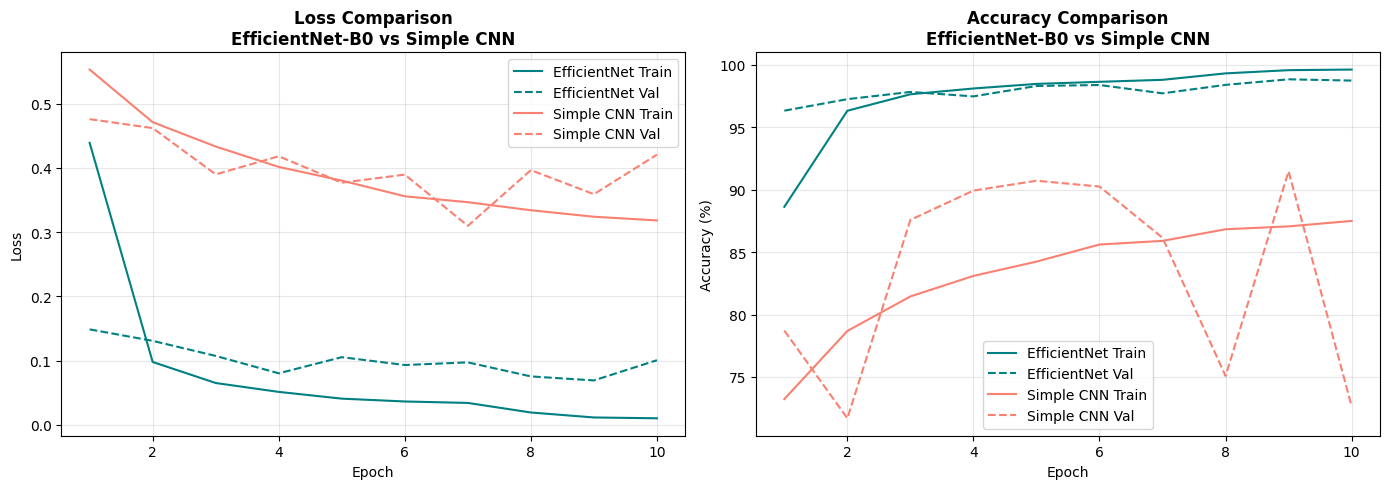

Saved: learning_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'],     label='EfficientNet Train', color='teal')
axes[0].plot(epochs_range, history['val_loss'],       label='EfficientNet Val',   color='teal',   linestyle='--')
axes[0].plot(epochs_range, cnn_history['train_loss'], label='Simple CNN Train',   color='salmon')
axes[0].plot(epochs_range, cnn_history['val_loss'],   label='Simple CNN Val',     color='salmon', linestyle='--')
axes[0].set_title('Loss Comparison\nEfficientNet-B0 vs Simple CNN', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, history['train_acc'],     label='EfficientNet Train', color='teal')
axes[1].plot(epochs_range, history['val_acc'],       label='EfficientNet Val',   color='teal',   linestyle='--')
axes[1].plot(epochs_range, cnn_history['train_acc'], label='Simple CNN Train',   color='salmon')
axes[1].plot(epochs_range, cnn_history['val_acc'],   label='Simple CNN Val',     color='salmon', linestyle='--')
axes[1].set_title('Accuracy Comparison\nEfficientNet-B0 vs Simple CNN', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{save_dir}/learning_curves.png', dpi=150)
plt.show()
print('Saved: learning_curves.png')

## Step 9 : Evaluation on Test Set

We evaluate the best EfficientNet-B0 model on the **held-out test set** (45,000 images never seen during training or validation).

Metrics we compute:
- **Accuracy** : overall % correct
- **F1-Score** : harmonic mean of precision and recall (better than accuracy for imbalanced data)
- **AUC-ROC** : area under the ROC curve (1.0 = perfect, 0.5 = random)
- **Confusion Matrix** : shows exactly which classes are confused

> Because our dataset is imbalanced, we focus on **F1-Score and AUC** rather than raw accuracy.

In [ ]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs= torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


#  EfficientNet-B0 evaluation 
y_true, y_pred, y_prob = evaluate(model, test_loader, device)

acc = 100 * (y_true == y_pred).mean()
f1= f1_score(y_true, y_pred, average='weighted')
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

print('=' * 50)
print('EfficientNet-B0 — Test Set Results')
print('=' * 50)
print(f'Accuracy  : {acc:.2f}%')
print(f'F1-Score  : {f1:.4f}')
print(f'AUC-ROC   : {roc_auc:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=class_names))

EfficientNet-B0 — Test Set Results
Accuracy  : 92.43%
F1-Score  : 0.9291
AUC-ROC   : 0.9912

              precision    recall  f1-score   support

        FAKE       0.99      0.91      0.95     37500
        REAL       0.69      0.98      0.81      7500

    accuracy                           0.92     45000
   macro avg       0.84      0.95      0.88     45000
weighted avg       0.94      0.92      0.93     45000



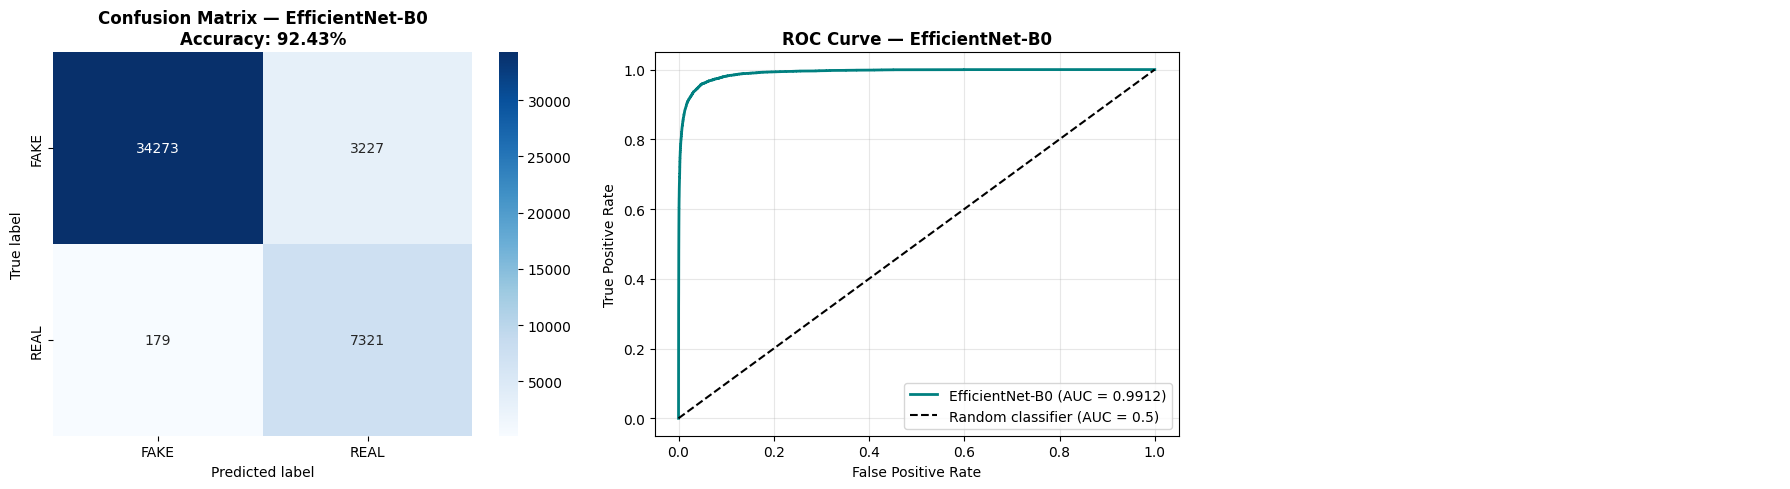

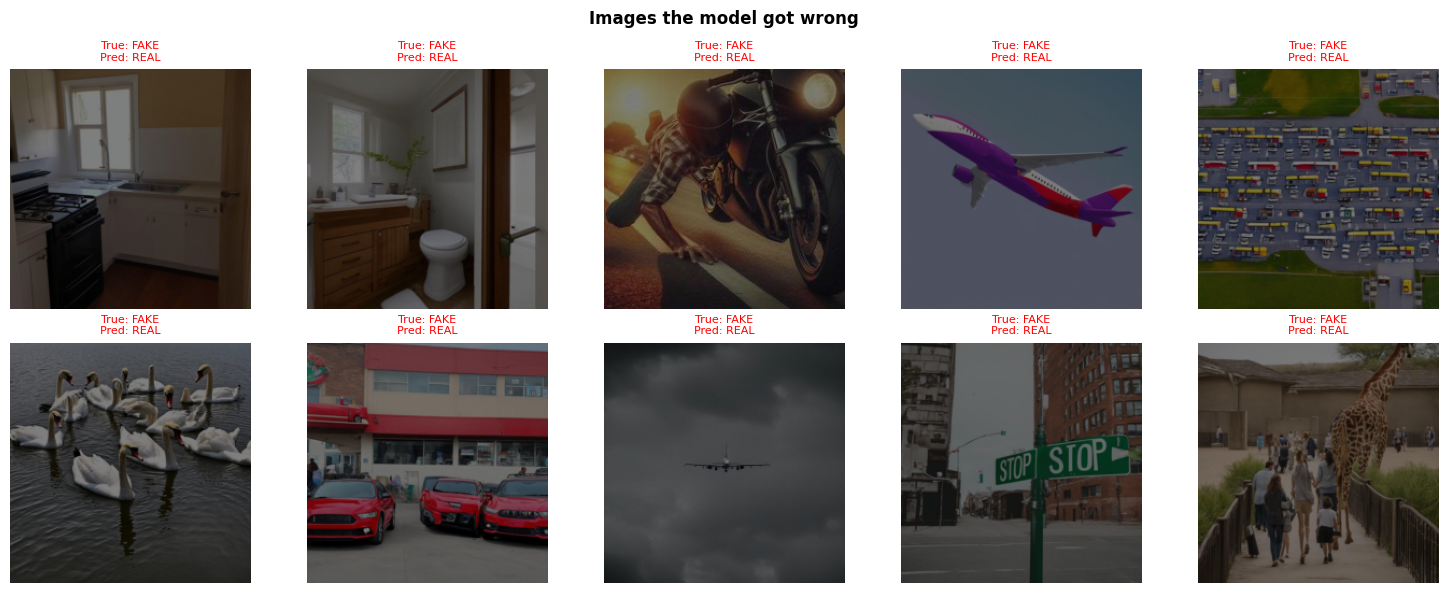

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix 
cm_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Confusion Matrix — EfficientNet-B0\nAccuracy: {acc:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# ROC Curve
axes[1].plot(fpr, tpr, color='teal', lw=2, label=f'EfficientNet-B0 (AUC = {roc_auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', label='Random classifier (AUC = 0.5)')
axes[1].set_title('ROC Curve — EfficientNet-B0', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

#  Misclassified images 
wrong_idx = np.where(y_true != y_pred)[0][:10]
for i, idx in enumerate(wrong_idx[:10]):
    img_tensor, _ = test_set[idx]
    rgb = inv_normalize(img_tensor).permute(1,2,0).numpy()
    rgb = np.clip(rgb, 0, 1)
    if i < 5:
        axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'{save_dir}/evaluation.png', dpi=150)
plt.show()

# Show misclassified images separately 
wrong_idx = np.where(y_true != y_pred)[0][:10]
fig2, axes2 = plt.subplots(2, 5, figsize=(15, 6))
for i, idx in enumerate(wrong_idx):
    img_tensor, _ = test_set[idx]
    rgb = inv_normalize(img_tensor).permute(1,2,0).numpy()
    rgb = np.clip(rgb, 0, 1)
    axes2[i//5, i%5].imshow(rgb)
    axes2[i//5, i%5].set_title(
        f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
        color='red', fontsize=8)
    axes2[i//5, i%5].axis('off')
plt.suptitle('Images the model got wrong', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{save_dir}/misclassified.png', dpi=150)
plt.show()

## Step 10 : Grad-CAM Attention Maps

**Grad-CAM (Gradient-weighted Class Activation Mapping)** shows us **which regions of the image the model focused on** when making its decision.

It works by computing the gradient of the predicted class score with respect to the feature maps of the last convolutional layer  then weighting those feature maps to produce a heatmap.

- **Red/warm areas** : the model paid close attention here
- **Blue/cold areas** : the model largely ignored these regions

For AI-generated images, we expect the model to focus on:
- Unnatural textures in backgrounds
- Overly smooth skin or surfaces
- Artifacts in fine details (edges, reflections)

For real images, the model should focus on natural imperfections and organic patterns.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 20.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


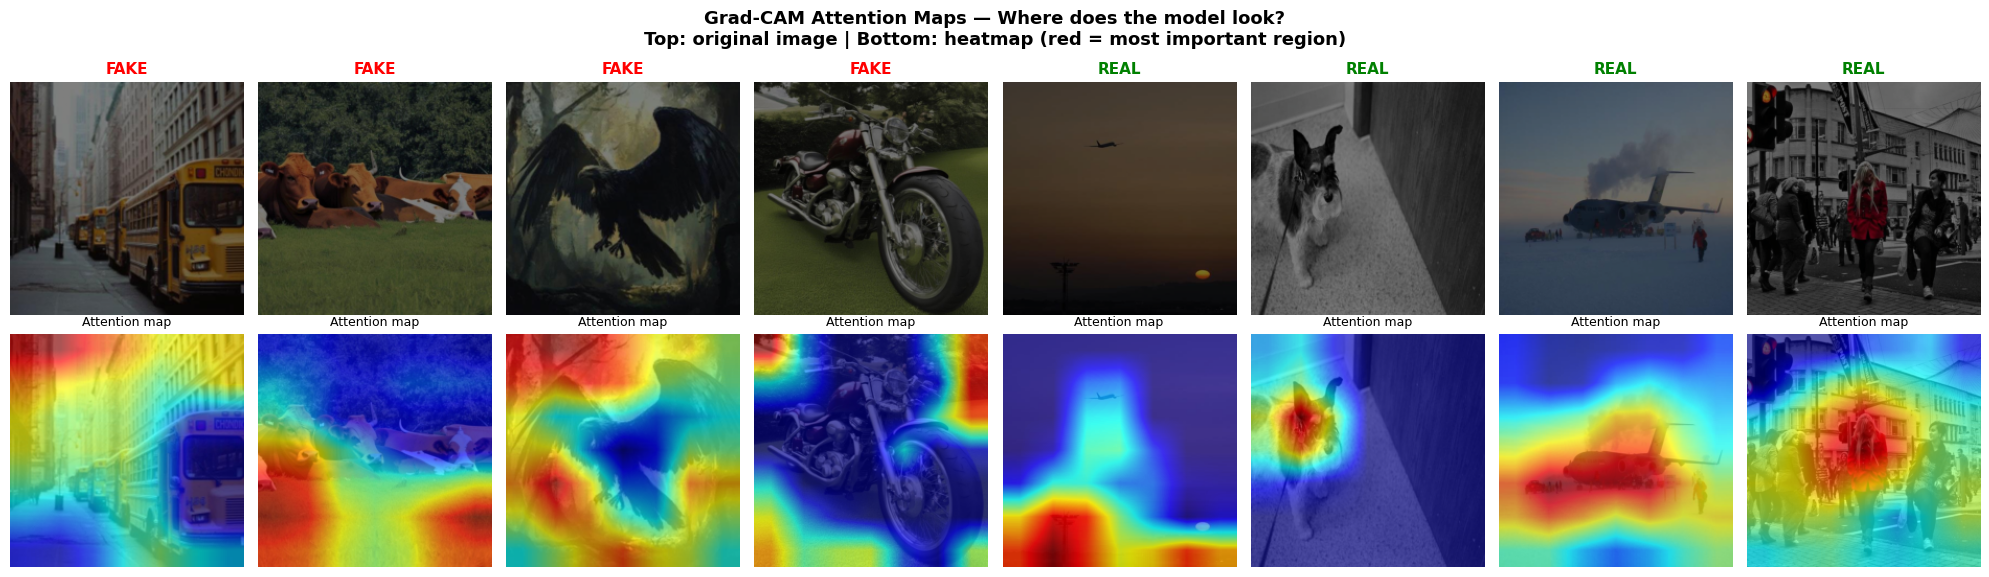

Saved: gradcam.png


In [ ]:
!pip install grad-cam --quiet
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# EfficientNet-B0 target layer — last convolutional block
target_layers = [model.blocks[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Pick 4 REAL and 4 FAKE images from the test set
real_indices = [i for i, (_, l) in enumerate(test_set) if l == 1][:4]
fake_indices = [i for i, (_, l) in enumerate(test_set) if l == 0][:4]
sample_indices = fake_indices + real_indices

fig, axes = plt.subplots(2, 8, figsize=(20, 6))

for col, idx in enumerate(sample_indices):
    img_tensor, label = test_set[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    targets          = [ClassifierOutputTarget(label)]
    grayscale_cam    = cam(input_tensor=input_tensor, targets=targets)[0]

    rgb_img = inv_normalize(img_tensor).permute(1, 2, 0).numpy()
    rgb_img = np.clip(rgb_img, 0, 1).astype(np.float32)

    # Original image (top row)
    axes[0, col].imshow(rgb_img)
    axes[0, col].set_title(
        class_names[label],
        color='green' if label == 1 else 'red',
        fontsize=11, fontweight='bold'
    )
    axes[0, col].axis('off')

    # Grad-CAM overlay (bottom row)
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    axes[1, col].imshow(visualization)
    axes[1, col].set_title('Attention map', fontsize=9)
    axes[1, col].axis('off')

plt.suptitle(
    'Grad-CAM Attention Maps — Where does the model look?\n'
    'Top: original image | Bottom: heatmap (red = most important region)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{save_dir}/gradcam.png', dpi=150)
plt.show()
print('Saved: gradcam.png')

## Step 11 : Save Model for Deployment

We save the best EfficientNet-B0 model in two formats:
1. **`.pth` file** : PyTorch native format for reloading in Python
2. **`.pkl` file** : pickle format used by the Streamlit app

This model is saved as `efficientnet_general.pkl` : the **general scene specialist** in our dual-model app. When the app receives an image that does NOT contain a face, this model handles the prediction.

In [ ]:
torch.save(model.state_dict(), f'{save_dir}/best_efficientnet_general.pth')
print('Saved: best_efficientnet_general.pth')
model_info = {
    'model_name' : 'efficientnet_b0',
    'num_classes'  : 2,
    'class_names': ['FAKE', 'REAL'],
    'state_dict': model.state_dict(),
    'input_size': 224,
    'mean' : [0.485, 0.456, 0.406],
    'std' : [0.229, 0.224, 0.225],
    'dataset': 'Defactify (HuggingFace) : general scenes & objects',
    'specialist': 'general',  
    'test_accuracy': acc,
    'f1_score' : f1,
    'auc': roc_auc
}

with open(f'{save_dir}/efficientnet_general.pkl', 'wb') as f:
    pickle.dump(model_info, f)
print('Saved: efficientnet_general.pkl')
for fname in ['best_efficientnet_general.pth', 'efficientnet_general.pkl']:
    size = os.path.getsize(f'{save_dir}/{fname}') / (1024 * 1024)
    print(f'   {fname}: {size:.1f} MB')

print()


Saved: best_efficientnet_general.pth
Saved: efficientnet_general.pkl
   best_efficientnet_general.pth: 15.6 MB
   efficientnet_general.pkl: 15.6 MB

